# Analyse exploratoire des donnees (EDA)

Ce notebook correspond au point 5 de la consigne : statistiques descriptives, visualisations, correlations, detection d'anomalies et interpretation.

Donnees utilisees : table `reviews_clean` de la base `data/steam_reviews.duckdb`, produite par le pipeline ETL (`scripts/04_etl_pipeline.py`). 32 176 434 avis, 506 jeux, langue anglaise uniquement.

Les agregations lourdes sont executees directement en SQL via DuckDB plutot que de charger l'integralite des 5.7 Go en memoire dans pandas. Seuls les resultats agreges, de taille reduite, sont manipules et affiches avec pandas et matplotlib.

In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

DATABASE_PATH = "data/steam_reviews.duckdb"
OUTPUT_DIR = "outputs/eda"
os.makedirs(OUTPUT_DIR, exist_ok=True)

con = duckdb.connect(DATABASE_PATH, read_only=True)
con.execute("SELECT COUNT(*) FROM reviews_clean").fetchone()

(32176434,)

## 1. Vue d'ensemble

Volume total, nombre de jeux distincts, et periode couverte par les avis. Ces trois chiffres cadrent l'ensemble de l'analyse qui suit.

In [2]:
overview = con.execute("""
    SELECT
        COUNT(*) AS total_avis,
        COUNT(DISTINCT game) AS nb_jeux,
        MIN(created_at) AS premiere_date,
        MAX(created_at) AS derniere_date
    FROM reviews_clean
""").fetchdf()
overview

,total_avis,nb_jeux,premiere_date,derniere_date
0,32176434,506,2010-10-16 00:27:49+02:00,2023-11-03 16:47:49+01:00


## 2. Statistiques descriptives

### 2.1 Repartition des avis positifs et negatifs

La colonne voted_up indique si l'avis recommande le jeu (1) ou non (0). Ce ratio sert de reference : un episode de review bombing se traduit par une chute brutale et localisee dans le temps de ce ratio pour un jeu donne, a distinguer d'une baisse progressive liee a une qualite de jeu qui se degrade reellement.

In [3]:
global_ratio = con.execute("""
    SELECT
        SUM(CASE WHEN voted_up = 1 THEN 1 ELSE 0 END) AS avis_positifs,
        SUM(CASE WHEN voted_up = 0 THEN 1 ELSE 0 END) AS avis_negatifs,
        ROUND(AVG(voted_up) * 100, 2) AS pourcentage_positif
    FROM reviews_clean
""").fetchdf()
global_ratio

,avis_positifs,avis_negatifs,pourcentage_positif
0,28431707.0,3744727.0,88.36


### 2.2 Longueur des avis et temps de jeu

La longueur du texte et le temps de jeu au moment de l'avis sont deux indicateurs de la fiabilite d'un avis : un avis tres court redige apres quelques minutes de jeu est un profil frequent dans les episodes de review bombing, ou l'auteur n'a pas necessairement teste le jeu en profondeur avant de reagir a un evenement exterieur (changement de prix, decision de l'editeur, actualite).

In [4]:
text_stats = con.execute("""
    SELECT
        ROUND(AVG(LENGTH(review)), 1) AS longueur_moyenne_avis,
        ROUND(MEDIAN(LENGTH(review)), 1) AS longueur_mediane_avis,
        ROUND(AVG(author_playtime_at_review) / 60.0, 1) AS temps_jeu_moyen_heures,
        ROUND(MEDIAN(author_playtime_at_review) / 60.0, 1) AS temps_jeu_median_heures
    FROM reviews_clean
""").fetchdf()
text_stats

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,longueur_moyenne_avis,longueur_mediane_avis,temps_jeu_moyen_heures,temps_jeu_median_heures
0,177.9,43.0,163.3,28.1


## 3. Visualisations

### 3.1 Volume d'avis par jeu

Classement des vingt jeux les plus reviewes dans le dataset filtre. Ce classement melange des jeux tres populaires sans controverse particuliere et des jeux ayant connu un episode documente de mecontentement, ce qui est le resultat attendu de la strategie de filtrage retenue (jeux populaires pour le volume, jeux a controverse pour disposer de cas reels a detecter).

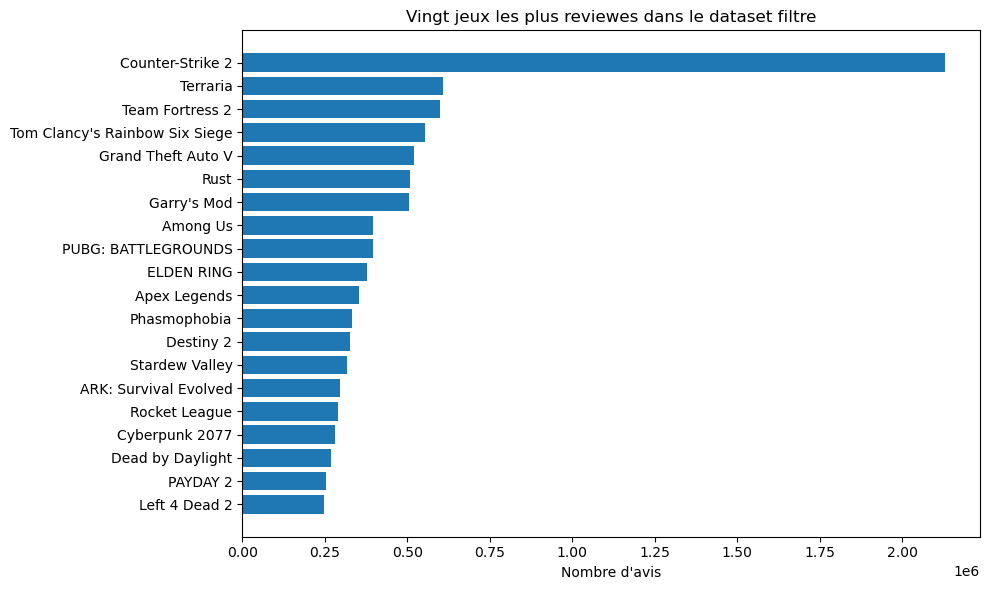

,game,n
0,Counter-Strike 2,2128846
1,Terraria,607273
2,Team Fortress 2,599620
3,Tom Clancy's Rainbow Six Siege,552541
4,Grand Theft Auto V,519874
5,Rust,506868
6,Garry's Mod,506231
7,Among Us,397041
8,PUBG: BATTLEGROUNDS,394984
9,ELDEN RING,379108


In [5]:
top_games = con.execute("""
    SELECT game, COUNT(*) AS n
    FROM reviews_clean
    GROUP BY game
    ORDER BY n DESC
    LIMIT 20
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_games["game"][::-1], top_games["n"][::-1])
ax.set_xlabel("Nombre d'avis")
ax.set_title("Vingt jeux les plus reviewes dans le dataset filtre")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "top_20_jeux.png"), dpi=150)
plt.show()
top_games

Counter-Strike 2 depasse a lui seul 2,1 millions d'avis, plus de trois fois Terraria (607 000). Le haut du classement est domine par des jeux multijoueurs en service continu, sans lien avec une controverse particuliere.

Cyberpunk 2077, l'un des trois cas de controverse retenus pour la suite, n'arrive qu'en dix-septieme position (280 360 avis) : sa notoriete vient d'un episode concentre sur quelques semaines, pas d'un volume soutenu dans la duree. Ce classement confirme que le volume total n'est pas un bon indicateur de review bombing, ce qui justifie la strategie de filtrage retenue en amont, combinant jeux populaires et jeux a controverse plutot qu'un simple classement par popularite.

### 3.2 Evolution mensuelle des avis pour trois jeux a controverse documentee

War Thunder (changement d'economie de jeu en mai 2023), Cyberpunk 2077 (lancement juge trop instable en decembre 2020) et Team Fortress 2 (protestation des joueurs contre l'inaction de Valve face aux bots en 2023 et 2024) ont chacun connu un episode documente. L'agregation mensuelle permet de reperer visuellement les periodes ou le volume d'avis s'ecarte fortement de la tendance habituelle du jeu, avant meme d'appliquer une methode statistique de detection.

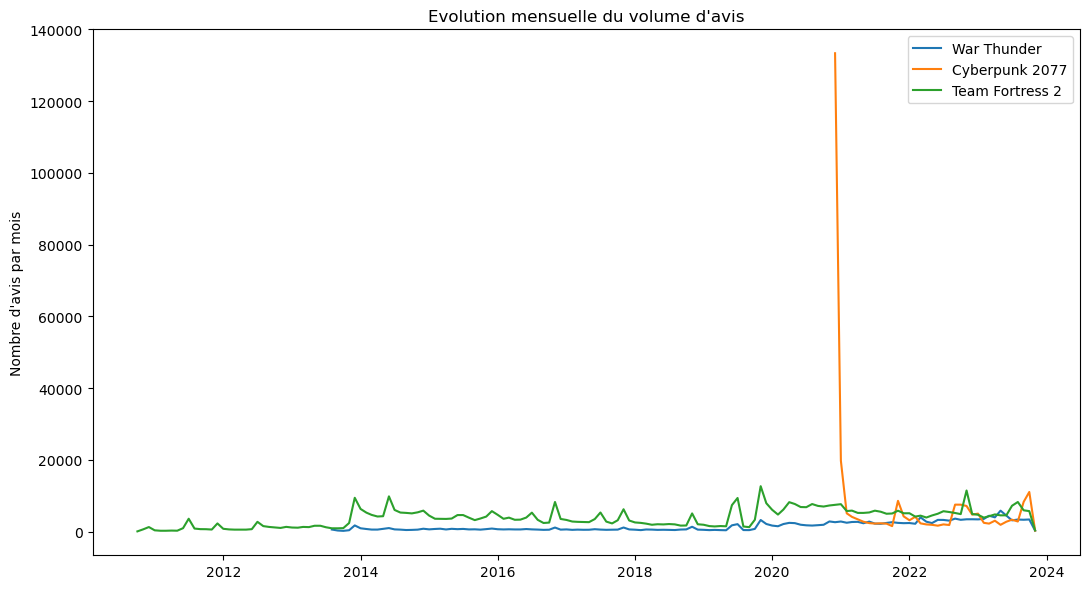

In [6]:
FOCUS_GAMES = ["War Thunder", "Cyberpunk 2077", "Team Fortress 2"]

monthly = con.execute("""
    SELECT
        game,
        date_trunc('month', created_at) AS mois,
        COUNT(*) AS n_avis,
        SUM(CASE WHEN voted_up = 0 THEN 1 ELSE 0 END) AS n_negatifs
    FROM reviews_clean
    WHERE game IN ?
    GROUP BY game, mois
    ORDER BY game, mois
""", [FOCUS_GAMES]).fetchdf()

fig, ax = plt.subplots(figsize=(11, 6))
for game in FOCUS_GAMES:
    subset = monthly[monthly["game"] == game]
    ax.plot(subset["mois"], subset["n_avis"], label=game)
ax.set_ylabel("Nombre d'avis par mois")
ax.set_title("Evolution mensuelle du volume d'avis")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "evolution_mensuelle_jeux_controverses.png"), dpi=150)
plt.show()

Le mois de lancement de Cyberpunk 2077 (decembre 2020) atteint environ 134 000 avis, tres au dessus du reste de la courbe, avant de retomber en quelques mois a un volume residuel de quelques centaines par mois. War Thunder et Team Fortress 2 restent dans une fourchette bien plus modeste tout au long de la periode, avec un pic isole en fin de serie correspondant aux episodes de 2023.

Cet ecart d'echelle ecrase visuellement les variations propres a War Thunder et Team Fortress 2. C'est pourquoi la detection d'anomalies de la section suivante calcule un seuil propre a chaque jeu plutot qu'un seuil commun : un pic discret ici peut representer une anomalie tres marquee rapportee au volume habituel du jeu concerne.

## 4. Correlations

Coefficients de correlation de Pearson calcules directement en SQL sur l'ensemble des 32 millions de lignes, sans echantillonnage. Quatre relations sont testees, en lien avec la fiabilite des avis et leur utilite percue :

- temps de jeu au moment de l'avis et recommandation (voted_up) : teste si les joueurs ayant plus joue recommandent davantage le jeu ;
- longueur de l'avis et votes utiles recus : teste si les avis plus longs sont juges plus utiles par la communaute ;
- score pondere Steam et votes utiles : verifie la coherence entre les deux mesures d'utilite fournies par la plateforme ;
- nombre d'avis deja rediges par l'auteur et recommandation : teste si les auteurs prolifiques ont un profil de notation different des auteurs occasionnels.

In [7]:
correlations = con.execute("""
    SELECT
        ROUND(CORR(author_playtime_at_review, voted_up), 3) AS playtime_vs_recommandation,
        ROUND(CORR(LENGTH(review), votes_up), 3) AS longueur_avis_vs_votes_utiles,
        ROUND(CORR(weighted_vote_score, votes_up), 3) AS score_pondere_vs_votes_utiles,
        ROUND(CORR(author_num_reviews, voted_up), 3) AS nb_avis_auteur_vs_recommandation
    FROM reviews_clean
""").fetchdf()
correlations

,playtime_vs_recommandation,longueur_avis_vs_votes_utiles,score_pondere_vs_votes_utiles,nb_avis_auteur_vs_recommandation
0,-0.029,0.052,0.092,-0.034


Les quatre coefficients sont tous proches de zero (entre -0.034 et 0.092). Le temps de jeu ne predit pas la recommandation (-0.029), la longueur de l'avis ne predit pas son utilite percue (0.052), le score pondere et les votes utiles ne sont que faiblement lies (0.092, donc non redondants entre eux), et le nombre d'avis de l'auteur n'a pas de lien avec sa tendance a recommander (-0.034).

Ces metadonnees numeriques prises isolement portent peu d'information predictive. Le modele de classification prevu en machine learning devra donc s'appuyer sur le contenu textuel des avis plutot que sur ces seules variables.

## 5. Detection d'anomalies : identification des episodes de review bombing

Principe retenu : pour chaque jeu, un episode de review bombing se traduit par un pic de volume d'avis largement superieur au volume habituel de ce meme jeu. Le seuil d'anomalie est donc calcule par jeu et non de maniere globale, puisque le volume normal varie enormement d'un titre a l'autre (Counter-Strike 2 recoit des millions d'avis, Titan Souls quelques milliers).

Methode : agregation du nombre d'avis par jour et par jeu, puis calcul d'un z-score sur ce volume quotidien, propre a chaque jeu (ecart a la moyenne du jeu, divise par l'ecart-type du jeu). Un jour est retenu comme anomalie si son z-score depasse 3, ce qui correspond a un volume tres largement hors norme pour ce jeu precis.

In [8]:
daily = con.execute("""
    SELECT
        game,
        date_trunc('day', created_at) AS jour,
        COUNT(*) AS n_avis,
        SUM(CASE WHEN voted_up = 0 THEN 1 ELSE 0 END) AS n_negatifs
    FROM reviews_clean
    WHERE game IN ?
    GROUP BY game, jour
    ORDER BY game, jour
""", [FOCUS_GAMES]).fetchdf()

daily["z_score_volume"] = daily.groupby("game")["n_avis"].transform(
    lambda x: (x - x.mean()) / x.std()
)
daily["anomalie"] = daily["z_score_volume"] > 3

anomalies = daily[daily["anomalie"]].sort_values(["game", "jour"])
anomalies[["game", "jour", "n_avis", "n_negatifs", "z_score_volume"]]

,game,jour,n_avis,n_negatifs,z_score_volume
0,Cyberpunk 2077,2020-12-10 00:00:00+01:00,19118,4243.0,16.630639
1,Cyberpunk 2077,2020-12-11 00:00:00+01:00,15935,2679.0,13.822698
2,Cyberpunk 2077,2020-12-12 00:00:00+01:00,16064,2646.0,13.936497
3,Cyberpunk 2077,2020-12-13 00:00:00+01:00,11424,1883.0,9.843237
4,Cyberpunk 2077,2020-12-14 00:00:00+01:00,9631,1602.0,8.261509
...,...,...,...,...,...
9189,War Thunder,2022-11-23 00:00:00+01:00,259,44.0,3.421730
9293,War Thunder,2023-03-07 00:00:00+01:00,237,34.0,3.064305
9364,War Thunder,2023-05-17 00:00:00+02:00,267,190.0,3.551702
9365,War Thunder,2023-05-18 00:00:00+02:00,1846,1602.0,29.205024


61 jours au total sont retenus comme anomalies sur les trois jeux. Celles de Cyberpunk 2077 se concentrent entierement sur la fenetre de lancement de decembre 2020, avec un z-score qui decroit progressivement de 16.6 a environ 8 : un seul evenement continu qui s'attenue.

War Thunder se distingue par les 18 et 19 mai 2023 (z-scores de 29.2 et 28.75), le double du z-score maximal de Cyberpunk 2077 et l'anomalie de volume la plus extreme de toute l'analyse, precedee d'une hausse plus moderee des le 17 mai (z-score de 3.55).

### 5.1 Visualisation des anomalies detectees

Les jours signales comme anomalies sont surimposes en points rouges sur la courbe du volume quotidien d'avis, jeu par jeu. Un point rouge isole, associe a une forte proportion d'avis negatifs sur ce meme jour, correspond au profil attendu d'un review bombing. Un point rouge sans hausse marquee du taux d'avis negatifs correspondrait davantage a un pic de popularite ponctuel (soldes, mise a jour majeure, evenement) qu'a une controverse.

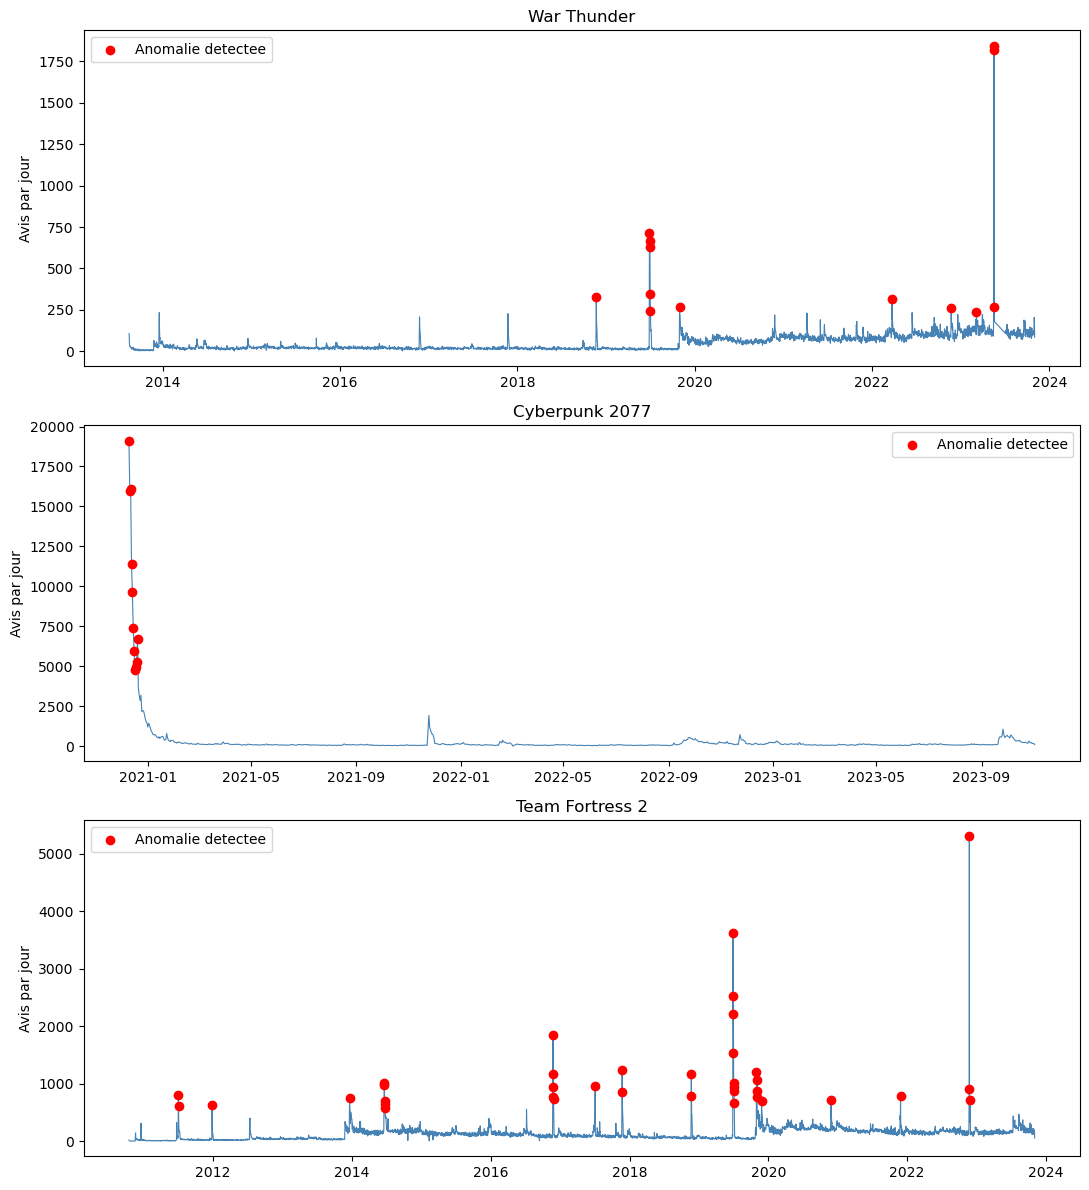

In [9]:
fig, axes = plt.subplots(len(FOCUS_GAMES), 1, figsize=(11, 4 * len(FOCUS_GAMES)), sharex=False)

for ax, game in zip(axes, FOCUS_GAMES):
    subset = daily[daily["game"] == game]
    ax.plot(subset["jour"], subset["n_avis"], color="steelblue", linewidth=0.8)
    flagged = subset[subset["anomalie"]]
    ax.scatter(flagged["jour"], flagged["n_avis"], color="red", zorder=5, label="Anomalie detectee")
    ax.set_title(game)
    ax.set_ylabel("Avis par jour")
    ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "anomalies_review_bombing.png"), dpi=150)
plt.show()

War Thunder presente un pic isole a environ 1800 avis par jour en 2023, sept a huit fois son niveau habituel : l'anomalie visuellement la plus nette des trois jeux. Cyberpunk 2077 est domine par son pic de lancement, ce qui rend ses anomalies posterieures (2022, 2023) visuellement discretes malgre leur detection statistique. Team Fortress 2 se distingue par des anomalies dispersees sur toute la periode 2011-2024 plutot que concentrees sur un seul evenement, avec un pic recent (environ 5300 avis/jour) depassant meme le groupe observe en 2019.

### 5.2 Confirmation par le taux d'avis negatifs

Pour chaque jour signale comme anomalie de volume, le taux d'avis negatifs de ce jour est compare au taux moyen habituel du jeu. Un ecart important confirme un episode de mecontentement plutot qu'un simple pic de frequentation neutre ou positif.

In [10]:
daily["taux_negatif"] = daily["n_negatifs"] / daily["n_avis"]
taux_moyen_par_jeu = daily.groupby("game")["taux_negatif"].mean().rename("taux_negatif_moyen_jeu")

anomalies = daily[daily["anomalie"]].merge(taux_moyen_par_jeu, on="game")
anomalies["ecart_taux_negatif"] = anomalies["taux_negatif"] - anomalies["taux_negatif_moyen_jeu"]
anomalies[["game", "jour", "n_avis", "taux_negatif", "taux_negatif_moyen_jeu", "ecart_taux_negatif"]].sort_values("ecart_taux_negatif", ascending=False)

,game,jour,n_avis,taux_negatif,taux_negatif_moyen_jeu,ecart_taux_negatif
60,War Thunder,2023-05-19 00:00:00+02:00,1818,0.882838,0.262112,0.620727
59,War Thunder,2023-05-18 00:00:00+02:00,1846,0.867822,0.262112,0.605711
58,War Thunder,2023-05-17 00:00:00+02:00,267,0.711610,0.262112,0.449499
0,Cyberpunk 2077,2020-12-10 00:00:00+01:00,19118,0.221937,0.164664,0.057274
8,Cyberpunk 2077,2020-12-18 00:00:00+01:00,4934,0.182610,0.164664,0.017947
...,...,...,...,...,...,...
53,War Thunder,2019-07-03 00:00:00+02:00,245,0.114286,0.262112,-0.147826
51,War Thunder,2019-07-01 00:00:00+02:00,663,0.107089,0.262112,-0.155023
52,War Thunder,2019-07-02 00:00:00+02:00,344,0.101744,0.262112,-0.160367
54,War Thunder,2019-10-31 00:00:00+01:00,265,0.094340,0.262112,-0.167772


War Thunder occupe les trois premieres places du classement (17 au 19 mai 2023), avec un taux d'avis negatifs jusqu'a 88 %, 45 a 62 points au dessus de sa moyenne habituelle (26 %) : anomalie de volume et de negativite concentrees sur la meme fenetre, le signal de review bombing le plus net de l'analyse.

Le lancement de Cyberpunk 2077 se situe beaucoup plus bas dans ce classement, avec un ecart de seulement 5.7 points par rapport a sa moyenne : il s'agit surtout d'un pic d'attention majoritairement positif, pas d'un review bombing au sens strict. A l'oppose, plusieurs anomalies de volume de War Thunder affichent un taux negatif sous la moyenne du jeu, confirmant qu'un pic de volume seul ne suffit pas a signaler une controverse.

## 6. Interpretation generale

Sur les trois jeux etudies, seul War Thunder (17 au 19 mai 2023) constitue un review bombing confirme : anomalie de volume extreme (z-score de 29.2, la plus elevee de l'analyse) coincidant avec un taux d'avis negatifs de 88 %, tres au dessus de son comportement habituel.

Le lancement de Cyberpunk 2077, malgre un volume spectaculaire sur les graphiques, ne presente pas cette signature : son taux d'avis negatifs reste proche de sa moyenne habituelle. Il s'agit avant tout d'un pic d'attention lie a la sortie, majoritairement positif, ce qui illustre une limite du volume seul comme indicateur : un pic de popularite peut ressembler a un review bombing sans en etre un.

Cette distinction, combinee aux correlations faibles de la section 4, indique que ni les metadonnees numeriques ni le volume pris isolement ne suffisent a identifier un episode de review bombing. Le modele de classification prevu pour la partie machine learning devra combiner l'ecart de taux d'avis negatifs mis en evidence ici avec le contenu textuel des avis.

Cette analyse a ete menee sur trois jeux a titre d'illustration. La methode retenue (agregation quotidienne, z-score de volume propre a chaque jeu, comparaison du taux d'avis negatifs a la moyenne du jeu) s'applique de la meme maniere a l'ensemble des 506 jeux du dataset filtre, en changeant uniquement le contenu de la liste FOCUS_GAMES.